In [1]:
import os
from pathlib import Path

BASE = Path("../datasets")

paths = {
    "garbage": BASE / "garbage" / "piles of litter.v1i.yolov8",
    "pipeline": BASE / "pipeline" / "Pipeline Defects_Test.v1i.yolov8",
    "road": BASE / "road" / "UAV",
    "water": BASE / "water logging" / "water stagnation.v1i.yolov8 (1)"
}

print("=== PATH CHECK ===")

for name, p in paths.items():
    print(f"\n{name.upper()} → {p}")
    print("exists:", p.exists())

    # Optional deeper check (train/test/valid)
    for split in ["train", "test", "valid"]:
        split_path = p / split
        print(f"   {split} exists:", split_path.exists())

=== PATH CHECK ===

GARBAGE → ..\datasets\garbage\piles of litter.v1i.yolov8
exists: True
   train exists: True
   test exists: True
   valid exists: True

PIPELINE → ..\datasets\pipeline\Pipeline Defects_Test.v1i.yolov8
exists: True
   train exists: True
   test exists: True
   valid exists: True

ROAD → ..\datasets\road\UAV
exists: True
   train exists: True
   test exists: True
   valid exists: True

WATER → ..\datasets\water logging\water stagnation.v1i.yolov8 (1)
exists: True
   train exists: True
   test exists: True
   valid exists: True


In [3]:
from pathlib import Path
from PIL import Image
import hashlib

BASE = Path("../datasets")

DATASETS = {
    "garbage": BASE / "garbage" / "piles of litter.v1i.yolov8",
    "pipeline": BASE / "pipeline" / "Pipeline Defects_Test.v1i.yolov8",
    "road": BASE / "road" / "UAV",
    "water": BASE / "water logging" / "water stagnation.v1i.yolov8 (1)"
}

def file_hash(path):
    try:
        with open(path, "rb") as f:
            return hashlib.md5(f.read()).hexdigest()
    except:
        return None


def scan_split(img_dir, lbl_dir):
    img_dir = Path(img_dir)
    lbl_dir = Path(lbl_dir)

    imgs = list(img_dir.glob("*.*"))
    lbls = list(lbl_dir.glob("*.txt"))

    img_names = set(i.stem for i in imgs)
    lbl_names = set(l.stem for l in lbls)

    missing_labels = img_names - lbl_names
    missing_images = lbl_names - img_names

    empty_labels = 0
    bad_boxes = 0
    tiny_boxes = 0
    unreadable_labels = 0
    corrupt_images = 0
    ghost_labels = 0
    duplicate_images = 0
    long_paths = 0

    class_counts = {}
    image_hashes = {}

    # ---- LABEL CHECK ----
    for l in lbls:
        try:
            if not l.exists():
                ghost_labels += 1
                continue

            if len(str(l)) > 250:
                long_paths += 1

            lines = l.read_text(errors="ignore").strip().splitlines()

        except:
            unreadable_labels += 1
            continue

        if len(lines) == 0:
            empty_labels += 1
            continue

        for line in lines:
            parts = line.split()
            if len(parts) != 5:
                bad_boxes += 1
                continue

            try:
                cid = int(parts[0])
                x, y, w, h = map(float, parts[1:])
            except:
                bad_boxes += 1
                continue

            class_counts[cid] = class_counts.get(cid, 0) + 1

            if w <= 0 or h <= 0 or x < 0 or y < 0 or x > 1 or y > 1:
                bad_boxes += 1

            if w * h < 0.0005:
                tiny_boxes += 1

    # ---- IMAGE CHECK ----
    for img in imgs:
        try:
            if len(str(img)) > 250:
                long_paths += 1

            Image.open(img).verify()

            h = file_hash(img)
            if h:
                if h in image_hashes:
                    duplicate_images += 1
                else:
                    image_hashes[h] = img

        except:
            corrupt_images += 1

    return {
        "images": len(imgs),
        "labels": len(lbls),
        "missing_labels": len(missing_labels),
        "missing_images": len(missing_images),
        "empty_labels": empty_labels,
        "bad_boxes": bad_boxes,
        "tiny_boxes": tiny_boxes,
        "unreadable_labels": unreadable_labels,
        "ghost_labels": ghost_labels,
        "corrupt_images": corrupt_images,
        "duplicate_images": duplicate_images,
        "long_path_files": long_paths,
        "class_counts": class_counts
    }


print("\n========== FULL DATASET FORENSIC REPORT ==========")

for name, root in DATASETS.items():
    print(f"\n\n================ {name.upper()} ================")

    if not root.exists():
        print("❌ Path does not exist:", root)
        continue

    for split in ["train", "valid", "test"]:
        img_dir = root / split / "images"
        lbl_dir = root / split / "labels"

        if img_dir.exists() and lbl_dir.exists():
            print(f"\n---- {split} ----")
            result = scan_split(img_dir, lbl_dir)
            for k, v in result.items():
                print(f"{k:22}: {v}")
        else:
            print(f"\n---- {split} ---- ❌ Missing images/labels folder")


========== FULL DATASET FORENSIC REPORT ==========


================ GARBAGE ================

---- train ----
images                : 2079
labels                : 2079
missing_labels        : 0
missing_images        : 0
empty_labels          : 0
bad_boxes             : 0
tiny_boxes            : 0
unreadable_labels     : 0
ghost_labels          : 0
corrupt_images        : 0
duplicate_images      : 0
long_path_files       : 0
class_counts          : {0: 4502}

---- valid ----
images                : 97
labels                : 97
missing_labels        : 0
missing_images        : 0
empty_labels          : 0
bad_boxes             : 0
tiny_boxes            : 0
unreadable_labels     : 0
ghost_labels          : 0
corrupt_images        : 0
duplicate_images      : 0
long_path_files       : 0
class_counts          : {0: 301}

---- test ----
images                : 193
labels                : 193
missing_labels        : 0
missing_images        : 0
empty_labels          : 0
bad_boxes            

In [4]:
from pathlib import Path
from PIL import Image
import shutil
import hashlib

BASE = Path("../datasets")

DATASETS = {
    "garbage": BASE / "garbage" / "piles of litter.v1i.yolov8",
    "pipeline": BASE / "pipeline" / "Pipeline Defects_Test.v1i.yolov8",
    "road": BASE / "road" / "UAV",
    "water": BASE / "water logging" / "water stagnation.v1i.yolov8 (1)"
}

def file_hash(path):
    try:
        with open(path, "rb") as f:
            return hashlib.md5(f.read()).hexdigest()
    except:
        return None


def clean_dataset(name, root):

    print(f"\nCleaning {name.upper()}...")

    train_img = root / "train" / "images"
    train_lbl = root / "train" / "labels"

    if not train_img.exists():
        print("Train folder missing.")
        return

    clean_root = BASE / f"{name}_clean" / "train"
    clean_img = clean_root / "images"
    clean_lbl = clean_root / "labels"

    clean_img.mkdir(parents=True, exist_ok=True)
    clean_lbl.mkdir(parents=True, exist_ok=True)

    seen_hashes = set()

    removed = {
        "corrupt_images": 0,
        "duplicate_images": 0,
        "empty_labels": 0,
        "bad_boxes": 0,
        "tiny_boxes": 0,
        "removed_images_after_cleaning": 0
    }

    images = list(train_img.glob("*.*"))

    for img_path in images:

        label_path = train_lbl / (img_path.stem + ".txt")

        # 1️⃣ Skip if label missing
        if not label_path.exists():
            continue

        # 2️⃣ Check image corruption
        try:
            Image.open(img_path).verify()
        except:
            removed["corrupt_images"] += 1
            continue

        # 3️⃣ Remove duplicates
        h = file_hash(img_path)
        if h in seen_hashes:
            removed["duplicate_images"] += 1
            continue
        seen_hashes.add(h)

        # 4️⃣ Read and clean label
        try:
            lines = label_path.read_text().strip().splitlines()
        except:
            continue

        if len(lines) == 0:
            removed["empty_labels"] += 1
            continue

        clean_lines = []

        for line in lines:
            parts = line.split()
            if len(parts) != 5:
                removed["bad_boxes"] += 1
                continue

            try:
                cid = int(parts[0])
                x, y, w, h = map(float, parts[1:])
            except:
                removed["bad_boxes"] += 1
                continue

            # invalid values
            if w <= 0 or h <= 0 or x < 0 or y < 0 or x > 1 or y > 1:
                removed["bad_boxes"] += 1
                continue

            # tiny boxes
            if w * h < 0.0005:
                removed["tiny_boxes"] += 1
                continue

            clean_lines.append(line)

        if len(clean_lines) == 0:
            removed["removed_images_after_cleaning"] += 1
            continue

        # 5️⃣ Copy clean image and write clean label
        shutil.copy(img_path, clean_img / img_path.name)

        with open(clean_lbl / label_path.name, "w") as f:
            f.write("\n".join(clean_lines))

    print("Removed summary:", removed)
    print("Clean dataset saved to:", clean_root)


# 🔥 Run cleaning
for name, root in DATASETS.items():
    if root.exists():
        clean_dataset(name, root)


Cleaning GARBAGE...
Removed summary: {'corrupt_images': 0, 'duplicate_images': 0, 'empty_labels': 0, 'bad_boxes': 0, 'tiny_boxes': 0, 'removed_images_after_cleaning': 0}
Clean dataset saved to: ..\datasets\garbage_clean\train

Cleaning PIPELINE...
Removed summary: {'corrupt_images': 0, 'duplicate_images': 0, 'empty_labels': 0, 'bad_boxes': 3, 'tiny_boxes': 2, 'removed_images_after_cleaning': 1}
Clean dataset saved to: ..\datasets\pipeline_clean\train

Cleaning ROAD...
Removed summary: {'corrupt_images': 0, 'duplicate_images': 10, 'empty_labels': 2, 'bad_boxes': 0, 'tiny_boxes': 7, 'removed_images_after_cleaning': 0}
Clean dataset saved to: ..\datasets\road_clean\train

Cleaning WATER...
Removed summary: {'corrupt_images': 0, 'duplicate_images': 0, 'empty_labels': 5, 'bad_boxes': 195, 'tiny_boxes': 0, 'removed_images_after_cleaning': 152}
Clean dataset saved to: ..\datasets\water_clean\train


In [5]:
from pathlib import Path
from PIL import Image
import numpy as np

BASE = Path("../datasets")

CLEAN_DATASETS = {
    "garbage_clean": BASE / "garbage_clean",
    "pipeline_clean": BASE / "pipeline_clean",
    "road_clean": BASE / "road_clean",
    "water_clean": BASE / "water_clean"
}


def analyze_clean_dataset(name, root):

    print(f"\n================ {name.upper()} ================")

    train_img = root / "train" / "images"
    train_lbl = root / "train" / "labels"

    if not train_img.exists():
        print("❌ train folder missing")
        return

    imgs = list(train_img.glob("*.*"))
    lbls = list(train_lbl.glob("*.txt"))

    img_names = set(i.stem for i in imgs)
    lbl_names = set(l.stem for l in lbls)

    missing_labels = img_names - lbl_names
    missing_images = lbl_names - img_names

    empty_labels = 0
    bad_boxes = 0
    tiny_boxes = 0
    corrupt_images = 0

    class_counts = {}
    total_boxes = 0

    # ---- LABEL CHECK ----
    for l in lbls:
        lines = l.read_text().strip().splitlines()

        if len(lines) == 0:
            empty_labels += 1
            continue

        for line in lines:
            parts = line.split()
            if len(parts) != 5:
                bad_boxes += 1
                continue

            cid = int(parts[0])
            x, y, w, h = map(float, parts[1:])

            total_boxes += 1
            class_counts[cid] = class_counts.get(cid, 0) + 1

            if w <= 0 or h <= 0 or x < 0 or y < 0 or x > 1 or y > 1:
                bad_boxes += 1

            if w * h < 0.0005:
                tiny_boxes += 1

    # ---- IMAGE CHECK ----
    for img in imgs:
        try:
            Image.open(img).verify()
        except:
            corrupt_images += 1

    # ---- Class imbalance analysis ----
    if class_counts:
        max_class = max(class_counts.values())
        min_class = min(class_counts.values())
        imbalance_ratio = round(max_class / min_class, 2)
    else:
        imbalance_ratio = 0

    avg_boxes_per_image = round(total_boxes / len(imgs), 2) if imgs else 0

    print(f"Images                    : {len(imgs)}")
    print(f"Labels                    : {len(lbls)}")
    print(f"Missing labels            : {len(missing_labels)}")
    print(f"Missing images            : {len(missing_images)}")
    print(f"Empty labels              : {empty_labels}")
    print(f"Bad boxes                 : {bad_boxes}")
    print(f"Tiny boxes                : {tiny_boxes}")
    print(f"Corrupt images            : {corrupt_images}")
    print(f"Total boxes               : {total_boxes}")
    print(f"Avg boxes per image       : {avg_boxes_per_image}")
    print(f"Class counts              : {class_counts}")
    print(f"Class imbalance ratio     : {imbalance_ratio}")


print("\n========== CLEAN DATASET ANALYSIS ==========")

for name, root in CLEAN_DATASETS.items():
    if root.exists():
        analyze_clean_dataset(name, root)
    else:
        print(f"\n{name} ❌ Not found")


========== CLEAN DATASET ANALYSIS ==========

================ GARBAGE_CLEAN ================
Images                    : 2079
Labels                    : 2079
Missing labels            : 0
Missing images            : 0
Empty labels              : 0
Bad boxes                 : 0
Tiny boxes                : 0
Corrupt images            : 0
Total boxes               : 4502
Avg boxes per image       : 2.17
Class counts              : {0: 4502}
Class imbalance ratio     : 1.0

================ PIPELINE_CLEAN ================
Images                    : 1269
Labels                    : 1269
Missing labels            : 0
Missing images            : 0
Empty labels              : 0
Bad boxes                 : 0
Tiny boxes                : 0
Corrupt images            : 0
Total boxes               : 1875
Avg boxes per image       : 1.48
Class counts              : {0: 686, 1: 707, 2: 482}
Class imbalance ratio     : 1.47

================ ROAD_CLEAN ================
Images                    : 8

In [6]:
pip install albumentations opencv-python

In [9]:
import cv2
import random
import numpy as np
from pathlib import Path
import albumentations as A

# ==============================
# CONFIG
# ==============================

BASE = Path("../datasets")
TARGET_SIZE = 2000

DATASETS = {
    "pipeline_clean": BASE / "pipeline_clean",
    "water_clean": BASE / "water_clean"
}

# ==============================
# SAFE AUGMENTATION PIPELINE
# ==============================

transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.2),
        A.RandomBrightnessContrast(p=0.5),
        A.GaussianBlur(p=0.2),
        A.RandomGamma(p=0.3),
    ],
    bbox_params=A.BboxParams(
        format='yolo',
        label_fields=['class_labels'],
        min_visibility=0.1
    )
)

# ==============================
# HELPER FUNCTIONS
# ==============================

def clip_box(box):
    """Ensure YOLO bbox stays in valid range"""
    x, y, w, h = box
    x = float(np.clip(x, 0.0, 1.0))
    y = float(np.clip(y, 0.0, 1.0))
    w = float(np.clip(w, 0.0, 1.0))
    h = float(np.clip(h, 0.0, 1.0))
    return [x, y, w, h]


def load_yolo_label(label_path):
    """Load YOLO label safely (handles float class IDs)"""
    boxes = []
    class_ids = []

    if not label_path.exists():
        return boxes, class_ids

    lines = label_path.read_text().strip().splitlines()

    for line in lines:
        parts = line.split()

        if len(parts) < 5:
            continue

        # Convert class id safely (handles 0.0 format)
        try:
            cid = int(float(parts[0]))
        except:
            continue

        try:
            box = list(map(float, parts[1:5]))
        except:
            continue

        box = clip_box(box)

        if box[2] > 0 and box[3] > 0:
            class_ids.append(cid)
            boxes.append(box)

    return boxes, class_ids


def save_yolo_label(label_path, boxes, class_ids):
    """Save YOLO label safely"""
    with open(label_path, "w") as f:
        for cid, box in zip(class_ids, boxes):
            box = clip_box(box)
            f.write(f"{cid} {' '.join(map(str, box))}\n")


def fix_existing_labels(root):
    """Fix float class IDs permanently (optional but recommended)"""
    label_dir = root / "train" / "labels"

    for label_file in label_dir.glob("*.txt"):
        lines = label_file.read_text().strip().splitlines()
        new_lines = []

        for line in lines:
            parts = line.split()
            if len(parts) < 5:
                continue

            cid = int(float(parts[0]))
            coords = parts[1:5]

            new_lines.append(f"{cid} {' '.join(coords)}")

        label_file.write_text("\n".join(new_lines))


# ==============================
# MAIN AUGMENTATION FUNCTION
# ==============================

def augment_dataset(name, root):

    print(f"\n========== AUGMENTING {name.upper()} ==========")

    img_dir = root / "train" / "images"
    lbl_dir = root / "train" / "labels"

    if not img_dir.exists() or not lbl_dir.exists():
        print("Train folders not found. Skipping.")
        return

    # Step 1: Fix labels once
    fix_existing_labels(root)

    images = list(img_dir.glob("*.*"))
    current_count = len(images)

    print("Current images:", current_count)

    if current_count >= TARGET_SIZE:
        print("Already at or above target size.")
        return

    needed = TARGET_SIZE - current_count
    print("Images to generate:", needed)

    counter = 0

    while counter < needed:

        img_path = random.choice(images)
        label_path = lbl_dir / (img_path.stem + ".txt")

        image = cv2.imread(str(img_path))

        if image is None:
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        boxes, class_ids = load_yolo_label(label_path)

        if len(boxes) == 0:
            continue

        try:
            augmented = transform(
                image=image,
                bboxes=boxes,
                class_labels=class_ids
            )
        except:
            continue  # Skip rare numeric edge cases

        aug_boxes = augmented["bboxes"]
        aug_class_ids = augmented["class_labels"]

        if len(aug_boxes) == 0:
            continue

        aug_img = cv2.cvtColor(augmented["image"], cv2.COLOR_RGB2BGR)

        new_name = f"{img_path.stem}_aug_{counter}"
        new_img_path = img_dir / f"{new_name}.jpg"
        new_lbl_path = lbl_dir / f"{new_name}.txt"

        cv2.imwrite(str(new_img_path), aug_img)
        save_yolo_label(new_lbl_path, aug_boxes, aug_class_ids)

        counter += 1

        if counter % 100 == 0:
            print(f"Generated {counter}/{needed}")

    final_count = len(list(img_dir.glob("*.*")))
    print("Final image count:", final_count)


# ==============================
# RUN FOR BOTH DATASETS
# ==============================

for name, root in DATASETS.items():
    if root.exists():
        augment_dataset(name, root)


========== AUGMENTING PIPELINE_CLEAN ==========
Current images: 2000
Already at or above target size.

========== AUGMENTING WATER_CLEAN ==========
Current images: 1101
Images to generate: 899
Generated 100/899
Generated 200/899
Generated 300/899
Generated 400/899
Generated 500/899
Generated 600/899
Generated 700/899
Generated 800/899
Final image count: 2000


In [10]:
import cv2
from pathlib import Path
from collections import defaultdict
import numpy as np

BASE = Path("../datasets")

DATASETS = {
    "garbage_clean": BASE / "garbage_clean",
    "pipeline_clean": BASE / "pipeline_clean",
    "road_clean": BASE / "road_clean",
    "water_clean": BASE / "water_clean",
}

# --------------------------------------------
# Helper: Validate YOLO bounding box
# --------------------------------------------

def validate_box(box):
    x, y, w, h = box

    # range check
    if not (0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1):
        return "bad"

    # tiny box check
    if w < 0.005 or h < 0.005:
        return "tiny"

    return "ok"


# --------------------------------------------
# Main Analysis Function
# --------------------------------------------

def analyze_dataset(name, root):

    print(f"\n================ {name.upper()} ================")

    img_dir = root / "train" / "images"
    lbl_dir = root / "train" / "labels"

    if not img_dir.exists() or not lbl_dir.exists():
        print("Train folder missing.")
        return

    images = list(img_dir.glob("*.*"))
    labels = list(lbl_dir.glob("*.txt"))

    image_stems = {p.stem for p in images}
    label_stems = {p.stem for p in labels}

    missing_labels = image_stems - label_stems
    missing_images = label_stems - image_stems

    empty_labels = 0
    bad_boxes = 0
    tiny_boxes = 0
    corrupt_images = 0
    total_boxes = 0
    class_counts = defaultdict(int)

    # Check images
    for img_path in images:
        img = cv2.imread(str(img_path))
        if img is None:
            corrupt_images += 1

    # Check labels
    for lbl_path in labels:

        lines = lbl_path.read_text().strip().splitlines()

        if len(lines) == 0:
            empty_labels += 1
            continue

        for line in lines:
            parts = line.split()

            if len(parts) < 5:
                bad_boxes += 1
                continue

            try:
                cid = int(float(parts[0]))
                box = list(map(float, parts[1:5]))
            except:
                bad_boxes += 1
                continue

            status = validate_box(box)

            if status == "bad":
                bad_boxes += 1
                continue
            elif status == "tiny":
                tiny_boxes += 1

            class_counts[cid] += 1
            total_boxes += 1

    avg_boxes = round(total_boxes / len(images), 2) if images else 0

    if class_counts:
        max_class = max(class_counts.values())
        min_class = min(class_counts.values())
        imbalance = round(max_class / min_class, 2) if min_class > 0 else 0
    else:
        imbalance = 0

    # --------------------------------------------
    # Print Summary
    # --------------------------------------------

    print("Images                    :", len(images))
    print("Labels                    :", len(labels))
    print("Missing labels            :", len(missing_labels))
    print("Missing images            :", len(missing_images))
    print("Empty labels              :", empty_labels)
    print("Bad boxes                 :", bad_boxes)
    print("Tiny boxes                :", tiny_boxes)
    print("Corrupt images            :", corrupt_images)
    print("Total boxes               :", total_boxes)
    print("Avg boxes per image       :", avg_boxes)
    print("Class counts              :", dict(class_counts))
    print("Class imbalance ratio     :", imbalance)


# --------------------------------------------
# RUN ANALYSIS FOR ALL DATASETS
# --------------------------------------------

print("========== CLEAN DATASET ANALYSIS ==========")

for name, root in DATASETS.items():
    if root.exists():
        analyze_dataset(name, root)

========== CLEAN DATASET ANALYSIS ==========

================ GARBAGE_CLEAN ================
Images                    : 2079
Labels                    : 2079
Missing labels            : 0
Missing images            : 0
Empty labels              : 0
Bad boxes                 : 0
Tiny boxes                : 0
Corrupt images            : 0
Total boxes               : 4502
Avg boxes per image       : 2.17
Class counts              : {0: 4502}
Class imbalance ratio     : 1.0

================ PIPELINE_CLEAN ================
Images                    : 2000
Labels                    : 2000
Missing labels            : 0
Missing images            : 0
Empty labels              : 0
Bad boxes                 : 0
Tiny boxes                : 0
Corrupt images            : 0
Total boxes               : 2980
Avg boxes per image       : 1.49
Class counts              : {0: 1073, 1: 1112, 2: 795}
Class imbalance ratio     : 1.4

================ ROAD_CLEAN ================
Images                    : 8

In [11]:
import shutil
import random
from pathlib import Path
from tqdm import tqdm

BASE = Path("../datasets")

SOURCE_DATASETS = {
    "garbage": BASE / "garbage_clean",
    "pipeline": BASE / "pipeline_clean",
    "road": BASE / "road_clean",
    "water": BASE / "water_clean",
}

FINAL_CLASS_MAP = {
    "garbage": 0,
    "pipeline": 1,
    "road": 2,
    "water": 3,
}

TARGET_SIZE = 2000
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10


def create_structure(root):
    for split in ["train", "val", "test"]:
        (root / split / "images").mkdir(parents=True, exist_ok=True)
        (root / split / "labels").mkdir(parents=True, exist_ok=True)


def remap_label_file(src_label, dst_label, new_class_id):
    lines = src_label.read_text().strip().splitlines()
    new_lines = []

    for line in lines:
        parts = line.split()
        if len(parts) < 5:
            continue
        coords = parts[1:5]
        new_lines.append(f"{new_class_id} {' '.join(coords)}")

    dst_label.write_text("\n".join(new_lines))


def create_final_dataset(name, src_root):

    print(f"\nCreating {name}_final")

    final_root = BASE / f"{name}_final"
    create_structure(final_root)

    img_dir = src_root / "train" / "images"
    lbl_dir = src_root / "train" / "labels"

    images = list(img_dir.glob("*.*"))
    random.shuffle(images)

    selected_images = images[:TARGET_SIZE]

    train_end = int(TARGET_SIZE * TRAIN_RATIO)
    val_end = train_end + int(TARGET_SIZE * VAL_RATIO)

    train_images = selected_images[:train_end]
    val_images = selected_images[train_end:val_end]
    test_images = selected_images[val_end:]

    class_id = FINAL_CLASS_MAP[name]

    # ------------------ TRAIN ------------------
    for img_path in tqdm(train_images, desc="Train"):
        label_path = lbl_dir / (img_path.stem + ".txt")
        new_img = final_root / "train" / "images" / img_path.name
        new_lbl = final_root / "train" / "labels" / (img_path.stem + ".txt")

        shutil.copy(img_path, new_img)
        remap_label_file(label_path, new_lbl, class_id)

    # ------------------ VAL ------------------
    for img_path in tqdm(val_images, desc="Val"):
        label_path = lbl_dir / (img_path.stem + ".txt")
        new_img = final_root / "val" / "images" / img_path.name
        new_lbl = final_root / "val" / "labels" / (img_path.stem + ".txt")

        shutil.copy(img_path, new_img)
        remap_label_file(label_path, new_lbl, class_id)

    # ------------------ TEST ------------------
    for img_path in tqdm(test_images, desc="Test"):
        label_path = lbl_dir / (img_path.stem + ".txt")
        new_img = final_root / "test" / "images" / img_path.name
        new_lbl = final_root / "test" / "labels" / (img_path.stem + ".txt")

        shutil.copy(img_path, new_img)
        remap_label_file(label_path, new_lbl, class_id)

    print("Train:", len(train_images))
    print("Val:", len(val_images))
    print("Test:", len(test_images))


# RUN FOR ALL DATASETS
for name, root in SOURCE_DATASETS.items():
    if root.exists():
        create_final_dataset(name, root)


Creating garbage_final


Test: 100%|█████████████████████████████████████████████████████████████████████████| 200/200 [00:01<00:00, 112.81it/s]


Train: 1600
Val: 200
Test: 200

Creating pipeline_final


Test: 100%|██████████████████████████████████████████████████████████████████████████| 200/200 [00:02<00:00, 79.70it/s]


Train: 1600
Val: 200
Test: 200

Creating road_final


Test: 100%|█████████████████████████████████████████████████████████████████████████| 200/200 [00:01<00:00, 153.91it/s]


Train: 1600
Val: 200
Test: 200

Creating water_final


Test: 100%|█████████████████████████████████████████████████████████████████████████| 200/200 [00:01<00:00, 163.20it/s]

Train: 1600
Val: 200
Test: 200


In [12]:
import shutil
from pathlib import Path
from tqdm import tqdm

BASE = Path("../datasets")

FINAL_DATASETS = [
    BASE / "garbage_final",
    BASE / "pipeline_final",
    BASE / "road_final",
    BASE / "water_final",
]

MERGED_ROOT = BASE / "merged_final"

def create_structure(root):
    for split in ["train", "val", "test"]:
        (root / split / "images").mkdir(parents=True, exist_ok=True)
        (root / split / "labels").mkdir(parents=True, exist_ok=True)

create_structure(MERGED_ROOT)

for dataset in FINAL_DATASETS:

    print(f"\nMerging {dataset.name}")

    for split in ["train", "val", "test"]:

        img_dir = dataset / split / "images"
        lbl_dir = dataset / split / "labels"

        images = list(img_dir.glob("*.*"))

        for img_path in tqdm(images, desc=f"{dataset.name} - {split}"):

            label_path = lbl_dir / (img_path.stem + ".txt")

            # Add prefix to avoid filename collisions
            new_name = f"{dataset.name}_{img_path.name}"

            new_img = MERGED_ROOT / split / "images" / new_name
            new_lbl = MERGED_ROOT / split / "labels" / (new_name.replace(img_path.suffix, ".txt"))

            shutil.copy(img_path, new_img)
            shutil.copy(label_path, new_lbl)

print("\n✅ MERGING COMPLETE")


Merging garbage_final


garbage_final - test: 100%|██████████████████████████████████████████████████████████| 200/200 [00:03<00:00, 56.46it/s]



Merging pipeline_final


pipeline_final - test: 100%|█████████████████████████████████████████████████████████| 200/200 [00:04<00:00, 44.07it/s]



Merging road_final


road_final - test: 100%|█████████████████████████████████████████████████████████████| 200/200 [00:05<00:00, 39.74it/s]



Merging water_final


water_final - test: 100%|████████████████████████████████████████████████████████████| 200/200 [00:04<00:00, 43.25it/s]


✅ MERGING COMPLETE


In [13]:
import cv2
from pathlib import Path
from collections import defaultdict
import hashlib

# =====================================
# CONFIG
# =====================================

MERGED_ROOT = Path("../datasets/merged_final")

SPLITS = ["train", "val", "test"]

# =====================================
# UTILITIES
# =====================================

def validate_box(box):
    x, y, w, h = box
    if not (0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1):
        return False
    return True


def file_hash(path):
    """Used to detect identical images across splits"""
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()


# =====================================
# STEP 1 — FULL DATASET VALIDATION
# =====================================

print("\n========== STEP 1: DATASET VALIDATION ==========")

global_class_counts = defaultdict(int)

for split in SPLITS:

    print(f"\n----- {split.upper()} -----")

    img_dir = MERGED_ROOT / split / "images"
    lbl_dir = MERGED_ROOT / split / "labels"

    images = list(img_dir.glob("*.*"))
    labels = list(lbl_dir.glob("*.txt"))

    image_stems = {p.stem for p in images}
    label_stems = {p.stem for p in labels}

    missing_labels = image_stems - label_stems
    missing_images = label_stems - image_stems

    corrupt_images = 0
    empty_labels = 0
    bad_boxes = 0

    split_class_counts = defaultdict(int)

    # Check images
    for img_path in images:
        img = cv2.imread(str(img_path))
        if img is None:
            corrupt_images += 1

    # Check labels
    for lbl_path in labels:
        lines = lbl_path.read_text().strip().splitlines()

        if len(lines) == 0:
            empty_labels += 1
            continue

        for line in lines:
            parts = line.split()

            if len(parts) < 5:
                bad_boxes += 1
                continue

            try:
                cid = int(float(parts[0]))
                box = list(map(float, parts[1:5]))
            except:
                bad_boxes += 1
                continue

            if not validate_box(box):
                bad_boxes += 1
                continue

            split_class_counts[cid] += 1
            global_class_counts[cid] += 1

    print("Images:", len(images))
    print("Labels:", len(labels))
    print("Missing labels:", len(missing_labels))
    print("Missing images:", len(missing_images))
    print("Corrupt images:", corrupt_images)
    print("Empty labels:", empty_labels)
    print("Bad boxes:", bad_boxes)
    print("Class distribution:", dict(split_class_counts))

print("\nGLOBAL CLASS DISTRIBUTION:", dict(global_class_counts))


# =====================================
# STEP 2 — DATA LEAKAGE CHECK
# =====================================

print("\n========== STEP 2: DATA LEAKAGE CHECK ==========")

split_hashes = {}
split_original_names = {}

for split in SPLITS:

    img_dir = MERGED_ROOT / split / "images"
    images = list(img_dir.glob("*.*"))

    hashes = set()
    original_names = set()

    for img_path in images:
        # Hash check (detect identical image)
        h = file_hash(img_path)
        hashes.add(h)

        # Extract original name (remove dataset prefix)
        # Example: garbage_final_image123.jpg → image123
        parts = img_path.stem.split("_")
        original_name = "_".join(parts[2:]) if len(parts) > 2 else img_path.stem
        original_names.add(original_name)

    split_hashes[split] = hashes
    split_original_names[split] = original_names


# Check cross-split hash overlap
for s1 in SPLITS:
    for s2 in SPLITS:
        if s1 >= s2:
            continue

        hash_overlap = split_hashes[s1].intersection(split_hashes[s2])
        name_overlap = split_original_names[s1].intersection(split_original_names[s2])

        print(f"\n{s1.upper()} vs {s2.upper()}")
        print("Identical image overlap:", len(hash_overlap))
        print("Original name overlap:", len(name_overlap))

print("\n✅ VERIFICATION COMPLETE")


========== STEP 1: DATASET VALIDATION ==========

----- TRAIN -----
Images: 6400
Labels: 6400
Missing labels: 0
Missing images: 0
Corrupt images: 0
Empty labels: 0
Bad boxes: 0
Class distribution: {0: 3504, 1: 2381, 2: 3530, 3: 1982}

----- VAL -----
Images: 800
Labels: 800
Missing labels: 0
Missing images: 0
Corrupt images: 0
Empty labels: 0
Bad boxes: 0
Class distribution: {0: 392, 1: 301, 2: 456, 3: 238}

----- TEST -----
Images: 800
Labels: 800
Missing labels: 0
Missing images: 0
Corrupt images: 0
Empty labels: 0
Bad boxes: 0
Class distribution: {0: 425, 1: 298, 2: 494, 3: 252}

GLOBAL CLASS DISTRIBUTION: {0: 4321, 1: 2980, 2: 4480, 3: 2472}

========== STEP 2: DATA LEAKAGE CHECK ==========

TRAIN vs VAL
Identical image overlap: 3
Original name overlap: 0

TEST vs TRAIN
Identical image overlap: 3
Original name overlap: 0

TEST vs VAL
Identical image overlap: 2
Original name overlap: 0

✅ VERIFICATION COMPLETE


In [14]:
from pathlib import Path
from collections import defaultdict

MERGED_ROOT = Path("../datasets/merged_final")
SPLITS = ["train", "val", "test"]

image_count_per_class = defaultdict(int)
box_count_per_class = defaultdict(int)

for split in SPLITS:
    lbl_dir = MERGED_ROOT / split / "labels"
    labels = list(lbl_dir.glob("*.txt"))

    for lbl_path in labels:
        lines = lbl_path.read_text().strip().splitlines()

        classes_in_image = set()

        for line in lines:
            parts = line.split()
            if len(parts) < 5:
                continue

            cid = int(float(parts[0]))
            box_count_per_class[cid] += 1
            classes_in_image.add(cid)

        for cid in classes_in_image:
            image_count_per_class[cid] += 1


print("\n========== CLASS IMAGE DISTRIBUTION ==========")
print(dict(image_count_per_class))

print("\n========== CLASS BOX DISTRIBUTION ==========")
print(dict(box_count_per_class))

print("\n========== AVG BOXES PER IMAGE (PER CLASS) ==========")
for cid in box_count_per_class:
    avg = box_count_per_class[cid] / image_count_per_class[cid]
    print(f"Class {cid}: {round(avg,2)}")


========== CLASS IMAGE DISTRIBUTION ==========
{0: 2000, 1: 2000, 2: 2000, 3: 2000}

========== CLASS BOX DISTRIBUTION ==========
{0: 4321, 1: 2980, 2: 4480, 3: 2472}

========== AVG BOXES PER IMAGE (PER CLASS) ==========
Class 0: 2.16
Class 1: 1.49
Class 2: 2.24
Class 3: 1.24


In [15]:
import hashlib
import os
from pathlib import Path

MERGED_ROOT = Path("../datasets/merged_final")
SPLITS = ["train", "val", "test"]

def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hash_registry = {}

print("\n========== REMOVING DUPLICATES ==========")

for split in SPLITS:
    img_dir = MERGED_ROOT / split / "images"
    lbl_dir = MERGED_ROOT / split / "labels"

    images = list(img_dir.glob("*.*"))

    for img_path in images:
        h = file_hash(img_path)

        if h in hash_registry:
            # Duplicate found → remove current
            print(f"Removing duplicate from {split}: {img_path.name}")

            label_path = lbl_dir / (img_path.stem + ".txt")

            img_path.unlink()
            if label_path.exists():
                label_path.unlink()
        else:
            hash_registry[h] = split

print("✅ DUPLICATES REMOVED")


========== REMOVING DUPLICATES ==========
Removing duplicate from train: pipeline_final_7_jpg.rf.c991d8c87911dcd32aeb3d7463f45ff5_aug_652.jpg
Removing duplicate from train: pipeline_final_advice-needed-cold-water-pipe-corrosion-v0-no0qv57uxk4c1_webp_jpg.rf.69d8182949efd00d91c89b10849937c4_aug_702.jpg
Removing duplicate from train: water_final_image1260_jpeg.rf.c37ecef871c2951fd17e72f3467091a3_aug_894.jpg
Removing duplicate from train: water_final_image1447_jpeg.rf.35585a50dcac965b1df371eba76e5806_aug_601.jpg
Removing duplicate from train: water_final_image1448_jpeg.rf.c9fd6603ace11b4324e52729fb1b7824_aug_524.jpg
Removing duplicate from train: water_final_image1980_jpeg.rf.d980a10a49404a2f6ff82b869b1431a4_aug_523.jpg
Removing duplicate from train: water_final_image303_jpeg.rf.0ac923bb73f2331af1fd7399ea159158_aug_6.jpg
Removing duplicate from train: water_final_image770_jpeg.rf.706ddf409809ad04a3c601f1d1333a49_aug_511.jpg
Removing duplicate from val: water_final_image1645_jpeg.rf.35f8fe

In [16]:
import pandas as pd
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt

MERGED_ROOT = Path("../datasets/merged_final")
SPLITS = ["train", "val", "test"]

class_names = {
    0: "garbage",
    1: "pipeline",
    2: "road",
    3: "water"
}

image_count_per_class = defaultdict(int)
box_count_per_class = defaultdict(int)
split_stats = {}

# ---------------------------------
# Collect Statistics
# ---------------------------------

for split in SPLITS:

    img_dir = MERGED_ROOT / split / "images"
    lbl_dir = MERGED_ROOT / split / "labels"

    images = list(img_dir.glob("*.*"))
    labels = list(lbl_dir.glob("*.txt"))

    split_box_count = 0

    for lbl_path in labels:
        lines = lbl_path.read_text().strip().splitlines()
        classes_in_image = set()

        for line in lines:
            parts = line.split()
            if len(parts) < 5:
                continue

            cid = int(float(parts[0]))
            box_count_per_class[cid] += 1
            split_box_count += 1
            classes_in_image.add(cid)

        for cid in classes_in_image:
            image_count_per_class[cid] += 1

    split_stats[split] = {
        "Images": len(images),
        "Boxes": split_box_count
    }

# ---------------------------------
# Compute imbalance
# ---------------------------------

max_boxes = max(box_count_per_class.values())
min_boxes = min(box_count_per_class.values())
imbalance_ratio = round(max_boxes / min_boxes, 2)

# ---------------------------------
# Print Summary
# ---------------------------------

print("\n========== SPLIT STATISTICS ==========")
for split, stats in split_stats.items():
    print(split.upper(), stats)

print("\n========== IMAGE COUNT PER CLASS ==========")
for cid in class_names:
    print(class_names[cid], ":", image_count_per_class[cid])

print("\n========== BOX COUNT PER CLASS ==========")
for cid in class_names:
    print(class_names[cid], ":", box_count_per_class[cid])

print("\nClass Imbalance Ratio (box-level):", imbalance_ratio)

# ---------------------------------
# Create DataFrame for Paper
# ---------------------------------

df = pd.DataFrame({
    "Class": [class_names[c] for c in class_names],
    "Images": [image_count_per_class[c] for c in class_names],
    "Boxes": [box_count_per_class[c] for c in class_names]
})

df.to_csv("dataset_statistics.csv", index=False)

print("\n✅ dataset_statistics.csv saved")


========== SPLIT STATISTICS ==========
TRAIN {'Images': 6392, 'Boxes': 11388}
VAL {'Images': 797, 'Boxes': 1384}
TEST {'Images': 795, 'Boxes': 1463}

========== IMAGE COUNT PER CLASS ==========
garbage : 2000
pipeline : 1998
road : 2000
water : 1986

========== BOX COUNT PER CLASS ==========
garbage : 4321
pipeline : 2977
road : 4480
water : 2457

Class Imbalance Ratio (box-level): 1.82

✅ dataset_statistics.csv saved


In [17]:
import pandas as pd
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt

MERGED_ROOT = Path("../datasets/merged_final")
SPLITS = ["train", "val", "test"]

class_names = {
    0: "garbage",
    1: "pipeline",
    2: "road",
    3: "water"
}

image_count_per_class = defaultdict(int)
box_count_per_class = defaultdict(int)
split_stats = {}

# ---------------------------------
# Collect Statistics
# ---------------------------------

for split in SPLITS:

    img_dir = MERGED_ROOT / split / "images"
    lbl_dir = MERGED_ROOT / split / "labels"

    images = list(img_dir.glob("*.*"))
    labels = list(lbl_dir.glob("*.txt"))

    split_box_count = 0

    for lbl_path in labels:
        lines = lbl_path.read_text().strip().splitlines()
        classes_in_image = set()

        for line in lines:
            parts = line.split()
            if len(parts) < 5:
                continue

            cid = int(float(parts[0]))
            box_count_per_class[cid] += 1
            split_box_count += 1
            classes_in_image.add(cid)

        for cid in classes_in_image:
            image_count_per_class[cid] += 1

    split_stats[split] = {
        "Images": len(images),
        "Boxes": split_box_count
    }

# ---------------------------------
# Compute imbalance
# ---------------------------------

max_boxes = max(box_count_per_class.values())
min_boxes = min(box_count_per_class.values())
imbalance_ratio = round(max_boxes / min_boxes, 2)

# ---------------------------------
# Print Summary
# ---------------------------------

print("\n========== SPLIT STATISTICS ==========")
for split, stats in split_stats.items():
    print(split.upper(), stats)

print("\n========== IMAGE COUNT PER CLASS ==========")
for cid in class_names:
    print(class_names[cid], ":", image_count_per_class[cid])

print("\n========== BOX COUNT PER CLASS ==========")
for cid in class_names:
    print(class_names[cid], ":", box_count_per_class[cid])

print("\nClass Imbalance Ratio (box-level):", imbalance_ratio)

# ---------------------------------
# Create DataFrame for Paper
# ---------------------------------

df = pd.DataFrame({
    "Class": [class_names[c] for c in class_names],
    "Images": [image_count_per_class[c] for c in class_names],
    "Boxes": [box_count_per_class[c] for c in class_names]
})

df.to_csv("dataset_statistics.csv", index=False)

print("\n✅ dataset_statistics.csv saved")


========== SPLIT STATISTICS ==========
TRAIN {'Images': 6392, 'Boxes': 11388}
VAL {'Images': 797, 'Boxes': 1384}
TEST {'Images': 795, 'Boxes': 1463}

========== IMAGE COUNT PER CLASS ==========
garbage : 2000
pipeline : 1998
road : 2000
water : 1986

========== BOX COUNT PER CLASS ==========
garbage : 4321
pipeline : 2977
road : 4480
water : 2457

Class Imbalance Ratio (box-level): 1.82

✅ dataset_statistics.csv saved


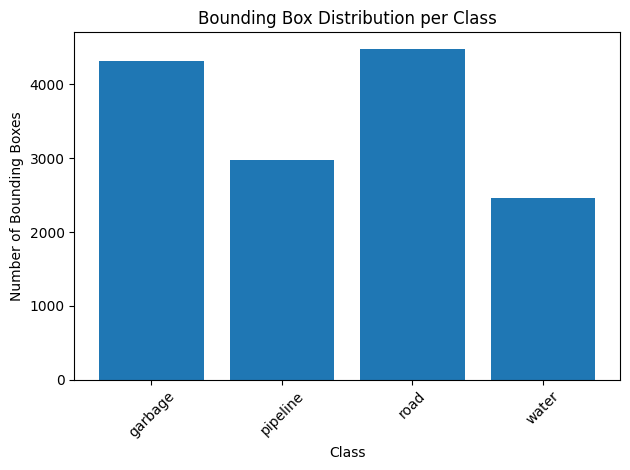

In [18]:
plt.figure()
plt.bar(df["Class"], df["Boxes"])
plt.xlabel("Class")
plt.ylabel("Number of Bounding Boxes")
plt.title("Bounding Box Distribution per Class")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("class_box_distribution.png", dpi=300)
plt.show()

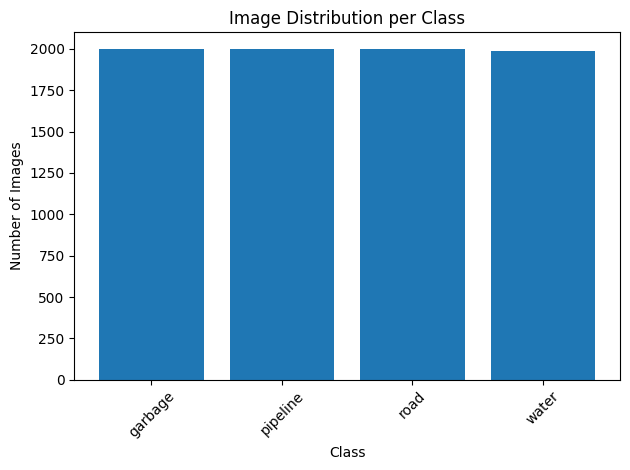

In [19]:
plt.figure()
plt.bar(df["Class"], df["Images"])
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Image Distribution per Class")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("class_image_distribution.png", dpi=300)
plt.show()

In [20]:
print("\n========== LATEX TABLE ==========\n")

print("\\begin{table}[h]")
print("\\centering")
print("\\begin{tabular}{lcc}")
print("\\hline")
print("Class & Images & Bounding Boxes \\\\")
print("\\hline")

for _, row in df.iterrows():
    print(f"{row['Class']} & {row['Images']} & {row['Boxes']} \\\\")

print("\\hline")
print("\\end{tabular}")
print("\\caption{Dataset distribution across classes.}")
print("\\end{table}")


========== LATEX TABLE ==========

\begin{table}[h]
\centering
\begin{tabular}{lcc}
\hline
Class & Images & Bounding Boxes \\
\hline
garbage & 2000 & 4321 \\
pipeline & 1998 & 2977 \\
road & 2000 & 4480 \\
water & 1986 & 2457 \\
\hline
\end{tabular}
\caption{Dataset distribution across classes.}
\end{table}


In [22]:
import os
from collections import defaultdict

# CHANGE THIS PATH
DATASET_PATH = "../datasets/merged_final"

SPLITS = ["train", "val", "test"]

def analyze_split(split_path):
    images_path = os.path.join(split_path, "images")
    labels_path = os.path.join(split_path, "labels")

    image_files = set([f.split('.')[0] for f in os.listdir(images_path)])
    label_files = set([f.split('.')[0] for f in os.listdir(labels_path)])

    class_box_count = defaultdict(int)
    class_image_count = defaultdict(int)

    total_boxes = 0

    for label_file in label_files:
        label_full_path = os.path.join(labels_path, label_file + ".txt")

        if not os.path.exists(label_full_path):
            continue

        image_has_class = set()

        with open(label_full_path, "r") as f:
            lines = f.readlines()

            for line in lines:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue

                cls = int(parts[0])
                class_box_count[cls] += 1
                total_boxes += 1
                image_has_class.add(cls)

        for cls in image_has_class:
            class_image_count[cls] += 1

    return {
        "total_images": len(image_files),
        "total_labels": len(label_files),
        "total_boxes": total_boxes,
        "boxes_per_class": dict(class_box_count),
        "images_per_class": dict(class_image_count)
    }


print("\n========== CLASS DISTRIBUTION REPORT ==========")

for split in SPLITS:
    print(f"\n----- {split.upper()} -----")

    split_path = os.path.join(DATASET_PATH, split)
    stats = analyze_split(split_path)

    print("Total Images:", stats["total_images"])
    print("Total Label Files:", stats["total_labels"])
    print("Total Boxes:", stats["total_boxes"])
    print("Images per Class:", stats["images_per_class"])
    print("Boxes per Class:", stats["boxes_per_class"])

print("\n✅ ANALYSIS COMPLETE")


========== CLASS DISTRIBUTION REPORT ==========

----- TRAIN -----
Total Images: 4115
Total Label Files: 4115
Total Boxes: 0
Images per Class: {}
Boxes per Class: {}

----- VAL -----
Total Images: 758
Total Label Files: 758
Total Boxes: 0
Images per Class: {}
Boxes per Class: {}

----- TEST -----
Total Images: 744
Total Label Files: 744
Total Boxes: 0
Images per Class: {}
Boxes per Class: {}

✅ ANALYSIS COMPLETE


In [24]:
import os

DATASET_PATH = "../datasets/merged_final"
SPLIT = "train"

labels_path = os.path.join(DATASET_PATH, SPLIT, "labels")

print("Labels path:", labels_path)
print("Exists:", os.path.exists(labels_path))

if os.path.exists(labels_path):
    files = os.listdir(labels_path)
    print("Number of label files:", len(files))
    print("First 5 label files:", files[:5])

Labels path: ../datasets/merged_final\train\labels
Exists: True
Number of label files: 6392
First 5 label files: ['garbage_final_-long-la-rue-C3A0-astoria-queens-new-york-un-tas-d-une-et-trottoir-213599590_jpg.rf.2e97102996feb367e76ee2966707c01a.txt', 'garbage_final_-vivait-avec-24-tonnes-de-dechets-chez-lui7C5ed3bed9f25151aba6a7f8d256c161c1_jpg.rf.6635839a9bc5ed0b3a0d0d78ffde9229.txt', 'garbage_final_-vivait-avec-24-tonnes-de-dechets-chez-lui7C5ed3bed9f25151aba6a7f8d256c161c1_jpg.rf.f73e48872e6ac6bcfef738c3955be6c9.txt', 'garbage_final_000568727W_jpg.rf.0ed502d0d52749fd2303cb4aecaf83e9.txt', 'garbage_final_000568727W_jpg.rf.b6b0075a4756579a55d98778619b8ccd.txt']


In [25]:
import os

DATASET_PATH = "../datasets/merged_final"
SPLIT = "train"

labels_path = os.path.join(DATASET_PATH, SPLIT, "labels")

print("Labels path:", labels_path)
print("Exists:", os.path.exists(labels_path))

if os.path.exists(labels_path):
    files = os.listdir(labels_path)
    print("Number of label files:", len(files))
    print("First 5 label files:", files[:5])

Labels path: ../datasets/merged_final\train\labels
Exists: True
Number of label files: 6392
First 5 label files: ['garbage_final_-long-la-rue-C3A0-astoria-queens-new-york-un-tas-d-une-et-trottoir-213599590_jpg.rf.2e97102996feb367e76ee2966707c01a.txt', 'garbage_final_-vivait-avec-24-tonnes-de-dechets-chez-lui7C5ed3bed9f25151aba6a7f8d256c161c1_jpg.rf.6635839a9bc5ed0b3a0d0d78ffde9229.txt', 'garbage_final_-vivait-avec-24-tonnes-de-dechets-chez-lui7C5ed3bed9f25151aba6a7f8d256c161c1_jpg.rf.f73e48872e6ac6bcfef738c3955be6c9.txt', 'garbage_final_000568727W_jpg.rf.0ed502d0d52749fd2303cb4aecaf83e9.txt', 'garbage_final_000568727W_jpg.rf.b6b0075a4756579a55d98778619b8ccd.txt']


In [26]:
import os

DATASET_PATH = "../datasets/merged_final"
SPLITS = ["train", "val", "test"]

all_classes_found = set()

for split in SPLITS:
    labels_path = os.path.join(DATASET_PATH, split, "labels")
    for file in os.listdir(labels_path):
        if not file.endswith(".txt"):
            continue
        with open(os.path.join(labels_path, file), "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    all_classes_found.add(parts[0])

print("All class IDs found in dataset:", sorted(all_classes_found))

All class IDs found in dataset: ['0', '1', '2', '3']


In [28]:
import os
from collections import defaultdict

DATASET_PATH = "../datasets/merged_final"
SPLITS = ["train", "val", "test"]
NUM_CLASSES = 4  # 0: garbage, 1: pipeline, 2: road, 3: water

global_image_count = defaultdict(int)
global_box_count = defaultdict(int)

def analyze_split(split_name):
    split_path = os.path.join(DATASET_PATH, split_name)
    images_path = os.path.join(split_path, "images")
    labels_path = os.path.join(split_path, "labels")

    image_files = set(os.listdir(images_path))
    label_files = [f for f in os.listdir(labels_path) if f.endswith(".txt")]

    class_image_count = defaultdict(int)
    class_box_count = defaultdict(int)

    for label_file in label_files:
        label_path = os.path.join(labels_path, label_file)
        with open(label_path, "r") as f:
            lines = [line.strip() for line in f if line.strip()]
        if not lines:
            continue

        image_classes_present = set()
        for line in lines:
            parts = line.split()
            if len(parts) != 5:
                continue
            cls = int(float(parts[0]))
            class_box_count[cls] += 1
            image_classes_present.add(cls)

        for cls in image_classes_present:
            class_image_count[cls] += 1

    # update global counters
    for cls in range(NUM_CLASSES):
        global_image_count[cls] += class_image_count[cls]
        global_box_count[cls] += class_box_count[cls]

    return class_image_count, class_box_count, len(image_files)

print("\n========== PER CLASS DISTRIBUTION ==========")
for split in SPLITS:
    img_count, box_count, total_imgs = analyze_split(split)
    print(f"\n----- {split.upper()} -----")
    print("Total Images:", total_imgs)
    for cls in range(NUM_CLASSES):
        print(f"Class {cls} → Images: {img_count[cls]} | Boxes: {box_count[cls]}")

print("\n----- GLOBAL TOTAL -----")
for cls in range(NUM_CLASSES):
    print(f"Class {cls} → Images: {global_image_count[cls]} | Boxes: {global_box_count[cls]}")

print("\n✅ CLASS ANALYSIS COMPLETE")


========== PER CLASS DISTRIBUTION ==========

----- TRAIN -----
Total Images: 6392
Class 0 → Images: 1600 | Boxes: 3504
Class 1 → Images: 1598 | Boxes: 2378
Class 2 → Images: 1600 | Boxes: 3530
Class 3 → Images: 1594 | Boxes: 1976

----- VAL -----
Total Images: 797
Class 0 → Images: 200 | Boxes: 392
Class 1 → Images: 200 | Boxes: 301
Class 2 → Images: 200 | Boxes: 456
Class 3 → Images: 197 | Boxes: 235

----- TEST -----
Total Images: 796
Class 0 → Images: 200 | Boxes: 425
Class 1 → Images: 200 | Boxes: 298
Class 2 → Images: 200 | Boxes: 494
Class 3 → Images: 195 | Boxes: 246

----- GLOBAL TOTAL -----
Class 0 → Images: 2000 | Boxes: 4321
Class 1 → Images: 1998 | Boxes: 2977
Class 2 → Images: 2000 | Boxes: 4480
Class 3 → Images: 1986 | Boxes: 2457

✅ CLASS ANALYSIS COMPLETE
